In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("Data/query_errors_all.csv")
df['year'] = df['year'].astype(int)
df_mae = df[['query', 'region', 'MAE']]
df_mae_ext = pd.get_dummies(
    df_mae,
    columns=["query", "region"],
    dtype="int8"
)

df_mae_ext.columns = df_mae_ext.columns.str.replace("^query_", "", regex=True)
#df_mae_ext.columns = df_mae_ext.columns.str.replace("^region_", "", regex=True)

### Correlations

#### Respect Region

In [47]:
df_pivot = df.pivot_table(
    index="region",
    columns="query",
    values="MAE",
    aggfunc="mean"
)
df_pivot = df_pivot.loc[:, df_pivot.nunique() > 1]

NA eliminations

In [48]:
df_pivot.isna().sum()[df_pivot.isna().sum() > 0]

query
LUC emissions by LUT in a specified land use region          30
ag production in a specified land use region                 30
ag tech implied subsidy                                      28
ag tech yield in a specified land region                     30
aluminum inputs by tech (energy and feedstocks)               9
aluminum production by region                                 9
aluminum production by tech                                   9
aluminum production by tech and vintage                       9
district heat energy inputs by subsector                     27
district heat production by subsector (fuel)                 27
irrigation water consumption by ag tech                       1
irrigation water consumption by crop type                     1
irrigation water consumption by crop type and land region     1
irrigation water consumption by region                        1
irrigation water withdrawals by ag tech                       1
irrigation water withdrawals by cr

In [49]:
nan_counts = df_pivot.isna().sum()
cols_drop = nan_counts[nan_counts > 2].index
df_pivot = df_pivot.drop(columns=cols_drop)
df_pivot = df_pivot.fillna(0)   

In [50]:
df_list = []
threshold = 0.8
correlaciones_vars = df_pivot.corr(method = 'spearman') #usar mejor Spearman, rank correlation
columns_to_drop = set()

# Iterar sobre la matriz de correlación y eliminar las columnas con correlación > 0.95
for i in range(len(correlaciones_vars.columns)):
    for j in range(i):
        if abs(correlaciones_vars.iloc[i, j]) > threshold:
            colname = correlaciones_vars.columns[i]
            columns_to_drop.add(colname)
nvarsAntes = len(df_pivot.columns)        
df_pivot_2 = df_pivot.drop(columns=columns_to_drop)   
print(len(df_pivot.columns),'variables →',len(df_pivot_2.columns),'variables')
vars_minCorr_region = list(df_pivot_2.columns)

279 variables → 99 variables


0.7961876832844574


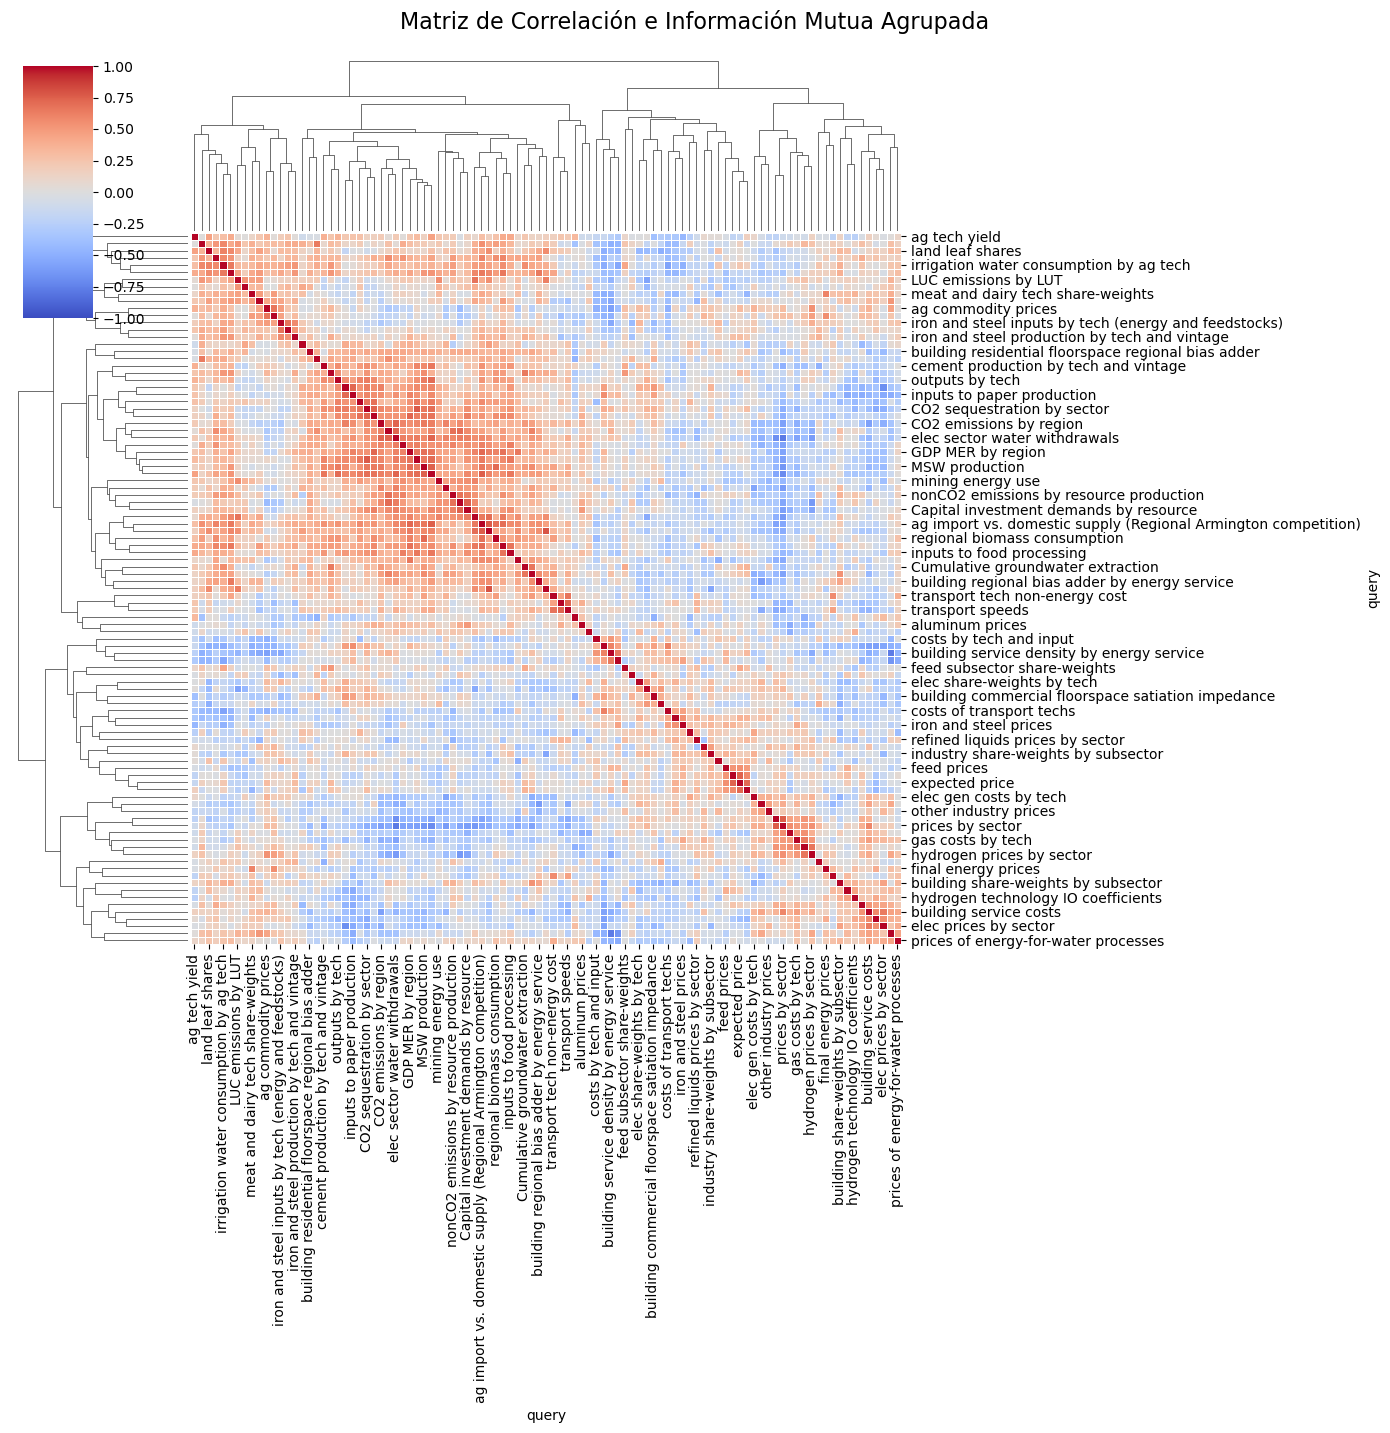

In [51]:

corr = df_pivot_2.corr(method='spearman')  

cluster = sns.clustermap(corr,
                         cmap='coolwarm',
                         vmin=-1, vmax=1,
                         figsize=(14, 14),
                         linewidths=0.5,
                         annot=False,
                         cbar_kws={"shrink": 0.7}
)
cluster.fig.suptitle('Matriz de Correlación e Información Mutua Agrupada', y=1.02, fontsize=16)

corr_no_diag = corr.where(~np.eye(corr.shape[0], dtype=bool))

max_corr = corr_no_diag.abs().max().max()

print(max_corr)

#### Respect year

In [58]:
df_year = df[df['year'].isin([1975, 1990, 2005, 2010, 2015, 2021, 2025, 2030])]
df_pivot = df_year.pivot_table(
    index="year",
    columns="query",
    values="MAE",
    aggfunc="mean"
)
df_pivot = df_pivot.loc[:, df_pivot.nunique() > 1]

Gestion NaNs

In [59]:
df_pivot = df_pivot.fillna(0)

In [ ]:
threshold = 0.9
correlaciones_vars = df_pivot.corr(method = 'spearman') #usar mejor Spearman, rank correlation
columns_to_drop = set()

# Iterar sobre la matriz de correlación y eliminar las columnas con correlación > 0.95
for i in range(len(correlaciones_vars.columns)):
    for j in range(i):
        if abs(correlaciones_vars.iloc[i, j]) > threshold:
            colname = correlaciones_vars.columns[i]
            columns_to_drop.add(colname)
nvarsAntes = len(df_pivot.columns)        
df_pivot_2 = df_pivot.drop(columns=columns_to_drop)   
print(len(df_pivot.columns),'variables →',len(df_pivot_2.columns),'variables')
vars_minCorr_year = list(df_pivot_2.columns)

285 variables → 24 variables


0.8783100656536799


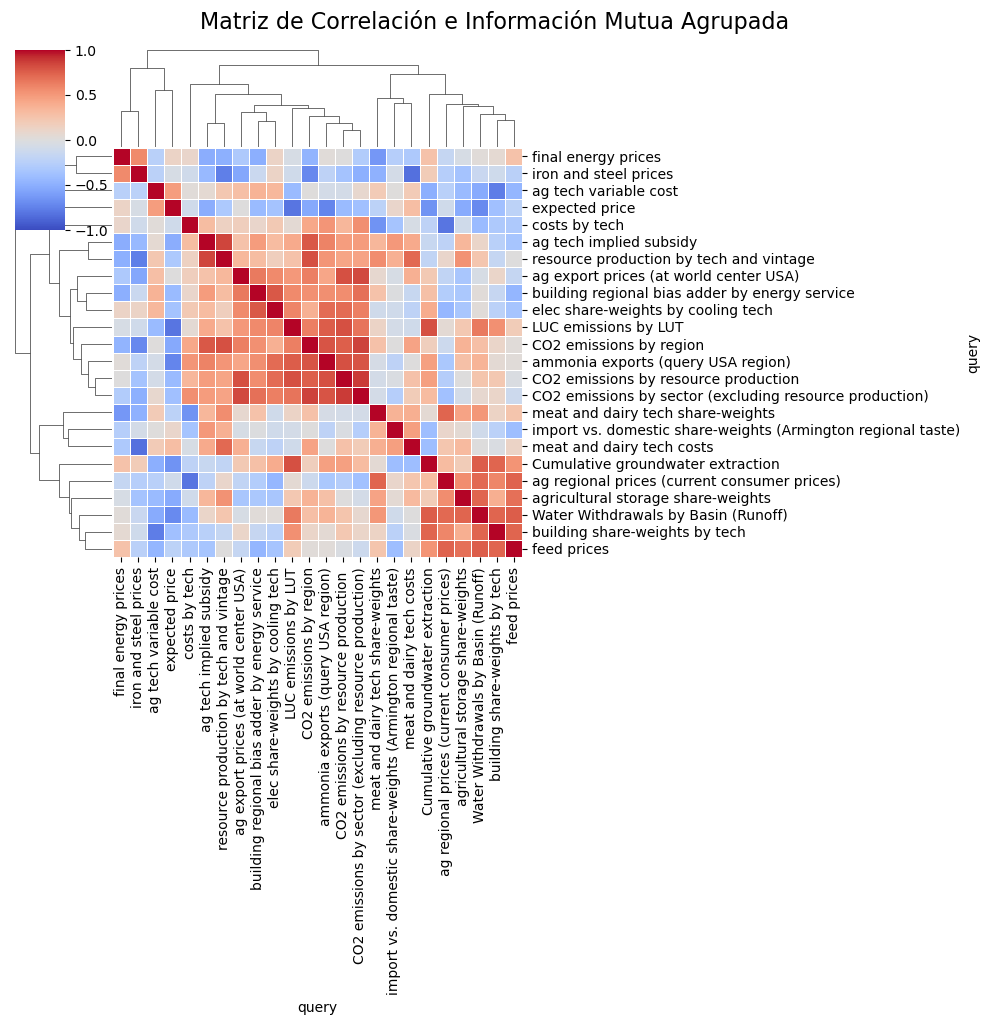

In [61]:

corr = df_pivot_2.corr(method='spearman')  

cluster = sns.clustermap(corr,
                         cmap='coolwarm',
                         vmin=-1, vmax=1,
                         #figsize=(14, 14),
                         linewidths=0.5,
                         annot=False,
                         cbar_kws={"shrink": 0.7}
)
cluster.fig.suptitle('Matriz de Correlación e Información Mutua Agrupada', y=1.02, fontsize=16)

corr_no_diag = corr.where(~np.eye(corr.shape[0], dtype=bool))

max_corr = corr_no_diag.abs().max().max()

print(max_corr)

In [63]:
n_inicial = len(df_mae_ext.columns)
df_mae_ext_1 = df_mae_ext[list(set(vars_minCorr_year + vars_minCorr_region))]
print(n_inicial,'->', len(df_mae_ext_1.columns))

335 -> 107


#### Respect vars errors

In [75]:
df_vars = pd.read_csv('Data/all_errors.csv', usecols= ['query',  'abs_error', 'resource', 'subresource', 'technology',
       'grade', 'fuel', 'subsector', 'output', 'sector', 'input', 'building',
       'nodeinput', 'building-node-input', 'gcam-consumer', 'mode', 'landleaf',
       'ghg', 'account', 'social-accounting-matrix-row', 'column', 'basin',
       'runoff water', 'groundwater'])

C:\Users\ignacio.delatorre\AppData\Local\Temp\ipykernel_35672\3439842285.py:1: DtypeWarning: Columns (8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df_vars = pd.read_csv('Data/all_errors.csv', usecols= ['query',  'abs_error', 'resource', 'subresource', 'technology',


In [76]:
vars = ['resource', 'subresource', 'technology',
       'grade', 'fuel', 'subsector', 'output', 'sector', 'input', 'building',
       'nodeinput', 'building-node-input', 'gcam-consumer', 'mode', 'landleaf',
       'ghg', 'account', 'social-accounting-matrix-row', 'column', 'basin',
       'runoff water', 'groundwater']

In [91]:
var = vars[1]
df_pivot = df_vars.pivot_table(
    index=var,
    columns="query",
    values="abs_error",
    aggfunc="mean"
)
df_pivot = df_pivot.fillna(df_pivot.mean())

In [92]:
df_pivot

query,Basin level available runoff,CO2 emissions by resource production,Capital investment demands by resource,Cumulative groundwater extraction,Water Withdrawals by Basin (Groundwater),Water Withdrawals by Basin (Runoff),Water withdrawals by water source (runoff vs. groundwater),nonCO2 emissions by resource production,nonrenewable groundwater pumping energy,resource production by tech and vintage,resource supply curves
subresource,,,,,,,,,,,
Residue,0.0,1.526897,2.809205,0.186913,0.013107,1.404911,0.076371,0.032845,0.003461,7.290110e+00,0.000000
Scavenging_Other,0.0,1.526897,2.809205,0.186913,0.013107,1.404911,0.076371,0.032845,0.003461,3.086469e+00,0.000000
bio_externality_cost,0.0,1.526897,2.809205,0.186913,0.013107,1.404911,0.076371,0.032845,0.003461,7.817450e-01,0.000000
coal,0.0,1.029012,0.921452,0.186913,0.013107,1.404911,0.076371,0.065718,0.003461,2.071997e-01,0.000000
crude oil,0.0,0.224808,3.754309,0.186913,0.013107,1.404911,0.076371,0.025849,0.003461,3.488341e-01,0.003200
distributed_solar,0.0,1.526897,2.809205,0.186913,0.013107,1.404911,0.076371,0.032845,0.003461,3.817758e-02,0.154021
generic waste biomass,0.0,1.526897,2.809205,0.186913,0.013107,1.404911,0.076371,0.032845,0.003461,1.712445e-02,0.154021
groundwater grade hist,0.0,1.526897,2.809205,3.049830,0.130951,1.404911,0.130951,0.032845,0.003461,8.154345e-01,4.902768
groundwater grade1,0.0,1.526897,2.809205,0.387045,0.060208,1.404911,0.060208,0.032845,0.015374,4.225381e+00,0.000000


In [87]:
threshold = 0.9
correlaciones_vars = df_pivot.corr(method = 'spearman') #usar mejor Spearman, rank correlation
columns_to_drop = set()

# Iterar sobre la matriz de correlación y eliminar las columnas con correlación > 0.95
for i in range(len(correlaciones_vars.columns)):
    for j in range(i):
        if abs(correlaciones_vars.iloc[i, j]) > threshold:
            colname = correlaciones_vars.columns[i]
            columns_to_drop.add(colname)
nvarsAntes = len(df_pivot.columns)        
df_pivot_2 = df_pivot.drop(columns=columns_to_drop)   
print(len(df_pivot.columns),'variables →',len(df_pivot_2.columns),'variables')
vars_minCorr_var = list(df_pivot_2.columns)

10 variables → 8 variables


In [88]:
vars_minCorr_var

['CO2 emissions by resource production ',
 'Capital investment demands by resource',
 'MSW production',
 'Water withdrawals by water source (runoff vs. groundwater)',
 'nonrenewable groundwater pumping energy',
 'resource production',
 'resource production by tech and vintage',
 'resource supply curves']

In [ ]:
df_all_errors = pd.read_csv("Data/all_errors.csv")
df_all_errors = df_all_errors[['query', 'abs_error']]
df_pivot_table = df_all_errors.pivot_table(
    index=df_all_errors.index,
    columns="query",
    values="abs_error",
    aggfunc="first"
)
df_pivot = df_pivot.fillna(df_pivot.mean())
threshold = 0.9
correlaciones_vars = df_pivot.corr(method = 'spearman') #usar mejor Spearman, rank correlation
columns_to_drop = set()

# Iterar sobre la matriz de correlación y eliminar las columnas con correlación > 0.95
for i in range(len(correlaciones_vars.columns)):
    for j in range(i):
        if abs(correlaciones_vars.iloc[i, j]) > threshold:
            colname = correlaciones_vars.columns[i]
            columns_to_drop.add(colname)
nvarsAntes = len(df_pivot.columns)        
df_pivot_2 = df_pivot.drop(columns=columns_to_drop)   
print(len(df_pivot.columns),'variables →',len(df_pivot_2.columns),'variables')
vars_minCorr_year = list(df_pivot_2.columns)

C:\Users\ignacio.delatorre\AppData\Local\Temp\ipykernel_27884\167899884.py:1: PerformanceWarning: The following operation may generate 4531562850 cells in the resulting pandas object.
  df_pivot_table = df_all_errors.pivot_table(


In [61]:
vars = ['resource', 'subresource', 'technology',
       'grade', 'fuel', 'subsector', 'output', 'sector', 'input', 'building',
       'nodeinput', 'building-node-input', 'gcam-consumer', 'mode', 'landleaf',
       'ghg', 'account', 'social-accounting-matrix-row', 'column', 'basin',
       'runoff water', 'groundwater']

In [62]:
var = vars[1]
df_var = df_all_errors[['query', 'abs_error', var]]
df_pivot = df_var.pivot_table(
    index=var,
    columns="query",
    values="abs_error",
    aggfunc="mean"
)
df_pivot = df_pivot.loc[:, df_pivot.nunique()/len(df_pivot) > 0.05]

In [63]:
df_pivot = df_pivot.fillna(df_pivot.mean())

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import sys

In [3]:
target = "MAE"
features = df_mae.columns.drop(target)
df_mae["MAE"] = np.log1p(np.abs(df_mae["MAE"]))


X = df_mae[features]
y = df_mae[target]

# 2. split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. model
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=10,
    oob_score=True,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

# 4. metrics
train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

r2_train = r2_score(y_train, train_pred)
r2_test = r2_score(y_test, test_pred)


mae_train = mean_absolute_error(y_train, train_pred)
mae_test = mean_absolute_error(y_test, test_pred)

importances = rf.feature_importances_


imp_df = pd.DataFrame({
    "feature": features,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print('R^2 train: ',r2_train)
print('R^2 test: ',r2_test)
print('MAE train:',mae_train)
print('MAE test:',mae_test)
print(imp_df.head(15))


R^2 train:  0.5591242457924619
R^2 test:  0.5399534571384157
MAE train: 0.6331936811369387
MAE test: 0.6283922943464022
                                               feature  importance
13                             query_GDP MER by region    0.461447
20                              query_National Account    0.302448
235                                  query_profit rate    0.096091
232                         query_population by region    0.058698
276          query_transport service output by service    0.025262
439                                        year_2030.0    0.014742
437                                        year_2021.0    0.007919
431                                        year_1975.0    0.005680
432                                        year_1990.0    0.004846
438                                        year_2025.0    0.004331
433                                        year_2005.0    0.004312
434                                        year_2010.0    0.003824
435      